HỒI QUY LOGISTIC VỚI KỸ THUẬT ĐIỀU CHỈNH

(REGULARIZED LOGISTIC REGRESSION)

In [75]:
import pandas as pd
import numpy as np
import os
from matplotlib import pyplot

In [76]:
path = os.getcwd() + '/data/ex2data2.txt'

In [77]:
tenCot = ['Test 1', 'Test 2', 'Accepted']
duLieu =pd.read_csv(path, names = tenCot)

print(duLieu.shape)

(118, 3)


In [78]:
print(duLieu.head())

     Test 1   Test 2  Accepted
0  0.051267  0.69956         1
1 -0.092742  0.68494         1
2 -0.213710  0.69225         1
3 -0.375000  0.50219         1
4 -0.513250  0.46564         1


In [79]:
print(duLieu.describe())

           Test 1      Test 2    Accepted
count  118.000000  118.000000  118.000000
mean     0.054779    0.183102    0.491525
std      0.496654    0.519743    0.502060
min     -0.830070   -0.769740    0.000000
25%     -0.372120   -0.254385    0.000000
50%     -0.006336    0.213455    0.000000
75%      0.478970    0.646563    1.000000
max      1.070900    1.108900    1.000000


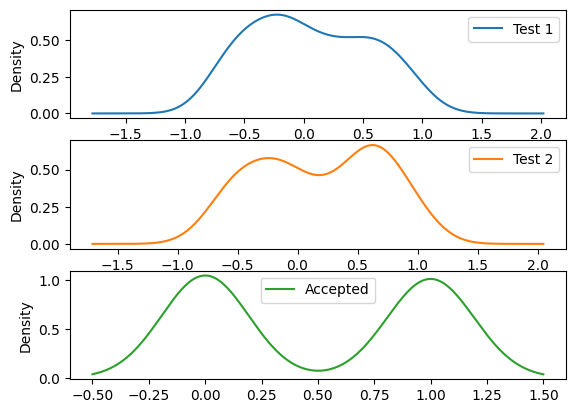

In [80]:
duLieu.plot(kind = 'density', subplots = True, sharex = False)
pyplot.show()

Ve Do Thi

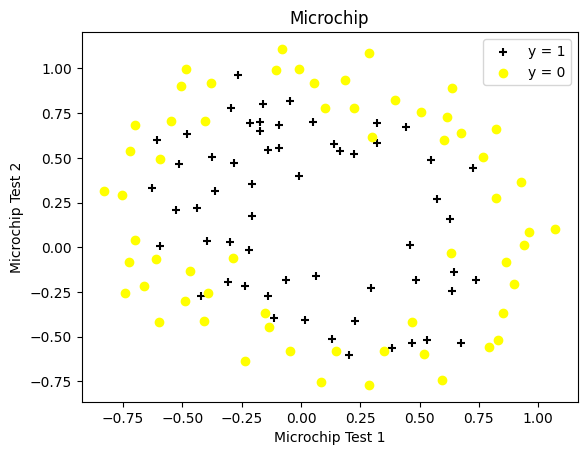

In [81]:
def doThi():
  do = duLieu[duLieu['Accepted'].isin([1])]
  truot = duLieu[duLieu['Accepted'].isin([0])]

  fig, ax = pyplot.subplots()
  ax.scatter(do['Test 1'], do['Test 2'], c= 'black', marker= '+', label= 'y = 1')
  ax.scatter(truot['Test 1'], truot['Test 2'], c ='yellow', marker='o', label ='y = 0')
  ax.legend() # thêm chú thích

  ax.set_xlabel('Microchip Test 1')
  ax.set_ylabel('Microchip Test 2')
  ax.set_title('Microchip')
  pyplot.show()
doThi()

Ánh xạ các đặc trưng

In [82]:
def mapfeatures():
  degree = 7
  x1 = duLieu['Test 1']
  x2 = duLieu['Test 2']
# hai cột 'Test 1' và 'Test 2' từ DataFrame duLieu và gán chúng vào các biến x1 và x2
  for i in range(0, degree):
    for j in range(0, degree - i):
        duLieu['F', str(i), str(j)] = np.power(x1, i) * np.power(x2, j)

  duLieu.drop('Test 1', axis=1, inplace=True)
  duLieu.drop('Test 2', axis=1, inplace=True)

  # Xóa cột 'Test 1' và 'Test 2' khỏi DataFrame duLieu, thay thế các đặc trưng ban đầu = new
mapfeatures()

Settings hàm chi phí và Gradient descent

In [83]:
maTran = duLieu.values                  # chuyển dữ liệu từ DataFrame thành 1 ma trận NumPy

print(duLieu[:5])                       # in ra 5 dòng đầu dữ liệu của DataFrame

   Accepted  (F, 0, 0)  (F, 0, 1)  (F, 0, 2)  (F, 0, 3)  (F, 0, 4)  (F, 0, 5)  \
0         1        1.0    0.69956   0.489384   0.342354   0.239497   0.167542   
1         1        1.0    0.68494   0.469143   0.321335   0.220095   0.150752   
2         1        1.0    0.69225   0.479210   0.331733   0.229642   0.158970   
3         1        1.0    0.50219   0.252195   0.126650   0.063602   0.031940   
4         1        1.0    0.46564   0.216821   0.100960   0.047011   0.021890   

   (F, 0, 6)  (F, 1, 0)  (F, 1, 1)  ...  (F, 3, 0)  (F, 3, 1)  (F, 3, 2)  \
0   0.117206   0.051267   0.035864  ...   0.000135   0.000094   0.000066   
1   0.103256  -0.092742  -0.063523  ...  -0.000798  -0.000546  -0.000374   
2   0.110047  -0.213710  -0.147941  ...  -0.009761  -0.006757  -0.004677   
3   0.016040  -0.375000  -0.188321  ...  -0.052734  -0.026483  -0.013299   
4   0.010193  -0.513250  -0.238990  ...  -0.135203  -0.062956  -0.029315   

   (F, 3, 3)  (F, 4, 0)  (F, 4, 1)  (F, 4, 2)     (F, 5,

In [84]:
m,n = maTran.shape                      # Từ ma trận gán giá trị số dòng vào biến m và số cột vào biến n
X = maTran[:, 1:n]                      # tạo ma trận đặc trưng X  bằng cách lấy các dòng của ma trận chỉ lấy từ cột 1 đến cột cuối
y = maTran[:, 0:1]                      # lấy cột đầu tiên

print(X[:5])                            # in 5 dòng đầu của X
print("\n")
print(y[:5])                            # in 5 dòng đầu của Y

[[ 1.00000000e+00  6.99560000e-01  4.89384194e-01  3.42353606e-01
   2.39496889e-01  1.67542444e-01  1.17205992e-01  5.12670000e-02
   3.58643425e-02  2.50892595e-02  1.75514423e-02  1.22782870e-02
   8.58939846e-03  2.62830529e-03  1.83865725e-03  1.28625106e-03
   8.99809795e-04  6.29470940e-04  1.34745327e-04  9.42624411e-05
   6.59422333e-05  4.61305487e-05  6.90798869e-06  4.83255257e-06
   3.38066048e-06  3.54151856e-07  2.47750473e-07  1.81563032e-08]
 [ 1.00000000e+00  6.84940000e-01  4.69142804e-01  3.21334672e-01
   2.20094970e-01  1.50751849e-01  1.03255971e-01 -9.27420000e-02
  -6.35227055e-02 -4.35092419e-02 -2.98012201e-02 -2.04120477e-02
  -1.39810280e-02  8.60107856e-03  5.89122275e-03  4.03513411e-03
   2.76382476e-03  1.89305413e-03 -7.97681228e-04 -5.46363780e-04
  -3.74226408e-04 -2.56322636e-04  7.39785525e-05  5.06708697e-05
   3.47065055e-05 -6.86091891e-06 -4.69931780e-06  6.36295342e-07]
 [ 1.00000000e+00  6.92250000e-01  4.79210063e-01  3.31733166e-01
   2.296

In [85]:
theta = np.zeros((1, X.shape[1]))       # tạo ma trận 0 có 1 dòng và X cột
print(X.shape, y.shape, theta.shape)    # in ra kích cỡ của X, y, theta
learningRate = 1                        # hệ số học nanda

(118, 28) (118, 1) (1, 28)


In [86]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def computeCost(theta, X, y, learningRate):
  theta = np.matrix(theta)                               # Chuyển đổi tham số theta thành ma trận
  h_theta = sigmoid(np.dot(X, theta.T))                  #

   #Tính hai thành phần của hàm chi phí
  first = np.multiply(-y, np.log(h_theta))
  second = np.multiply((1 - y), np.log(1 - h_theta))
  reg = (learningRate/(2*len(X))) * np.sum(np.power(theta[:, 1:theta.shape[1]], 2))
  return (np.sum(first - second) / len(X)) + reg

print(computeCost(theta, X, y, learningRate))
#in ra chi phí ban đầu

0.6931471805599454


Thuật toán Gradient descent

In [87]:
def gradientReg(theta, X, y, learningRate):
    theta = np.matrix(theta)
    X = np.matrix(X)
    y = np.matrix(y)

    parameters = theta.shape[1]
    grad = np.zeros(parameters)
    error = sigmoid(np.dot(X, theta.T)) -y

    for i in range(parameters):
        term = np.multiply(error, X[:, i])
        if (i == 0):
            grad[i] = np.sum(term) / len(X)
        else:
            grad[i] = (np.sum(term)/ len(X)) + ((learningRate/len(X))*theta[:, i])
    return grad

print(gradientReg(theta, X, y, learningRate))

[8.47457627e-03 7.77711864e-05 3.76648474e-02 2.34764889e-02
 3.93028171e-02 3.10079849e-02 3.87936363e-02 1.87880932e-02
 1.15013308e-02 8.19244468e-03 3.09593720e-03 4.47629067e-03
 1.37646175e-03 5.03446395e-02 7.32393391e-03 1.28600503e-02
 5.83822078e-03 7.26504316e-03 1.83559872e-02 2.23923907e-03
 3.38643902e-03 4.08503006e-04 3.93486234e-02 4.32983232e-03
 6.31570797e-03 1.99707467e-02 1.09740238e-03 3.10312442e-02]


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10600\396620705.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  grad[i] = (np.sum(term)/ len(X)) + ((learningRate/len(X))*theta[:, i])


In [88]:
import scipy.optimize as opt
result = opt.fmin_tnc(func=computeCost, x0=theta, fprime=gradientReg, args=(X, y, learningRate))
print(result)

(array([ 1.27271027,  1.18111686, -1.43166928, -0.17516291, -1.19271298,
       -0.45645981, -0.92467487,  0.62529965, -0.91743189, -0.35725403,
       -0.27469165, -0.29539513, -0.1438915 , -2.01987399, -0.36553118,
       -0.61558552, -0.27778953, -0.32742406,  0.12393227, -0.05098418,
       -0.04466179,  0.01555761, -1.45817009, -0.20603296, -0.29244873,
       -0.2421784 ,  0.02779373, -1.04319155]), 32, 1)


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10600\396620705.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  grad[i] = (np.sum(term)/ len(X)) + ((learningRate/len(X))*theta[:, i])


In [92]:
theta_sauCung = result[0]
def predict(theta, X):
  probability = sigmoid(np.dot(X, theta.T))
  return [1 if x >= 0.5 else 0 for x in probability]

predictions = predict(theta_sauCung, X)
soLanDoanDung = [1 if ((a == 1 and b == 1) or (a == 0 and b == 0))
                   else 0 for (a, b) in zip(predictions, y)]

doChinhXac = (sum(map(int, soLanDoanDung)) / len(y)*100)# predictions = y = soLanDoanDung

print('Do chinh xac = {0:2f}%'.format(doChinhXac))


Do chinh xac = 83.050847%


KeyError: 'Text 1'

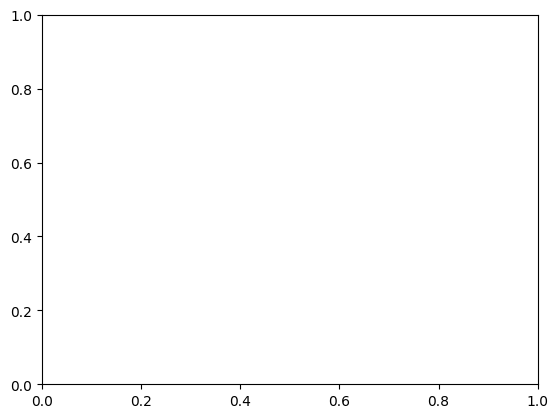

In [90]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

def plot_decision_boundary(X, y, model, ax):
    # Plot the decision boundary
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())

def doThi_fid():
    # Assuming duLieu is your DataFrame containing 'Text 1', 'Text 2', and 'Accepted' columns
    do = duLieu[duLieu['Accepted'].isin([1])]
    truot = duLieu[duLieu['Accepted'].isin([0])]

    # Scatter plot
    fig, ax = plt.subplots()
    ax.scatter(do['Text 1'], do['Text 2'], c= 'black', marker= '+', label= 'y = 1')
    ax.scatter(truot['Text 1'], truot['Text 2'], c ='yellow', marker='o', label ='y = 0')
    ax.legend() # add legend
    ax.set_xlabel('Microchip Text 1')
    ax.set_ylabel('Microchip Text 2')
    ax.set_title('Microchip')

    # Prepare data for training the logistic regression model
    X = duLieu[['Text 1', 'Text 2']].values
    y = duLieu['Accepted'].values

    # Train logistic regression model
    model = LogisticRegression()
    model.fit(X, y)

    # Plot decision boundary
    plot_decision_boundary(X, y, model, ax)
    plt.show()

doThi_fid()
